<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Exercise.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# Exercise: Probability and distributions


In this exercise, we test our understanding of statistical concepts, probability, and different types of distributions that can be used to analyse data using the stats package script in Python.



## Learning objectives

In this train, we will learn:
- Understand how to calculate basic statistical measures in Python.
- Learn how to calculate different probability distributions using the Scipy library.
- Apply statistical methods in Python to solve real-world scenarios.

## Exercises

### Exercise 1

Given a 1D Numpy array `temperatures` representing the daily average temperatures (in degrees Celsius) of a month, write a Python function named `describe_temperatures` that returns the mean, median, and standard deviation of the temperatures.


In [1]:
import numpy as np

temperatures = np.array([22, 25, 19, 21, 24, 28, 23, 20])

In [12]:
def describe_temperatures(temperatures):   
    mean   = np.mean(temperatures)
    median = np.median(temperatures)
    std    = np.std(temperatures)
    return mean, median, std

# Testing the function
temperatures = np.array([22, 25, 19, 21, 24, 28, 23, 20])
describe_temperatures(temperatures)

(22.75, 22.5, 2.7271780286589284)

### Exercise 2

Write a Python snippet that calculates the probability of observing a rare bird species at least once in a week in a national park, given the daily observation probability is 0.1. Use the binomial distribution from `scipy.stats`.


In [5]:
from scipy.stats import binom

n = 7  # Number of days in a week
p = 0.1  # Daily observation probability

from scipy.stats import binom

n = 7   # Number of days in a week
p = 0.1 # Daily observation probability

# P(X = 0) — probability of never observing the bird in 7 days
p_zero = binom.pmf(k=0, n=n, p=p)

# P(X >= 1) = 1 - P(X = 0)
p_at_least_once = 1 - p_zero

# Extra insight — full distribution across all possible observation days
print("===== Binomial Distribution Breakdown =====")
print(f"{'Days Observed (k)':<20} {'P(X = k)':>12} {'Cumulative P(X ≤ k)':>22}")
print("-" * 56)
for k in range(n + 1):
    pmf = binom.pmf(k=k, n=n, p=p)
    cdf = binom.cdf(k=k, n=n, p=p)
    print(f"{k:<20} {pmf:>12.4f} {cdf:>22.4f}")

print("\n===== Key Result =====")
print(f"P(never observed):        {p_zero:.4f}  ({p_zero*100:.2f}%)")
print(f"P(observed at least once): {p_at_least_once:.4f}  ({p_at_least_once*100:.2f}%)")

===== Binomial Distribution Breakdown =====
Days Observed (k)        P(X = k)    Cumulative P(X ≤ k)
--------------------------------------------------------
0                          0.4783                 0.4783
1                          0.3720                 0.8503
2                          0.1240                 0.9743
3                          0.0230                 0.9973
4                          0.0026                 0.9998
5                          0.0002                 1.0000
6                          0.0000                 1.0000
7                          0.0000                 1.0000

===== Key Result =====
P(never observed):        0.4783  (47.83%)
P(observed at least once): 0.5217  (52.17%)


### Exercise 3

Consider a discrete random variable `X`, which denotes the number of households in a neighbourhood that recycle out of 10 households. Assume that the recycling behaviours of the households are independent of each other and follow a binomial distribution, with each household having a fixed probability of 0.75 on deciding to recycle. Write a Python code snippet that calculates and plots the probability mass function (PMF) of `X`.

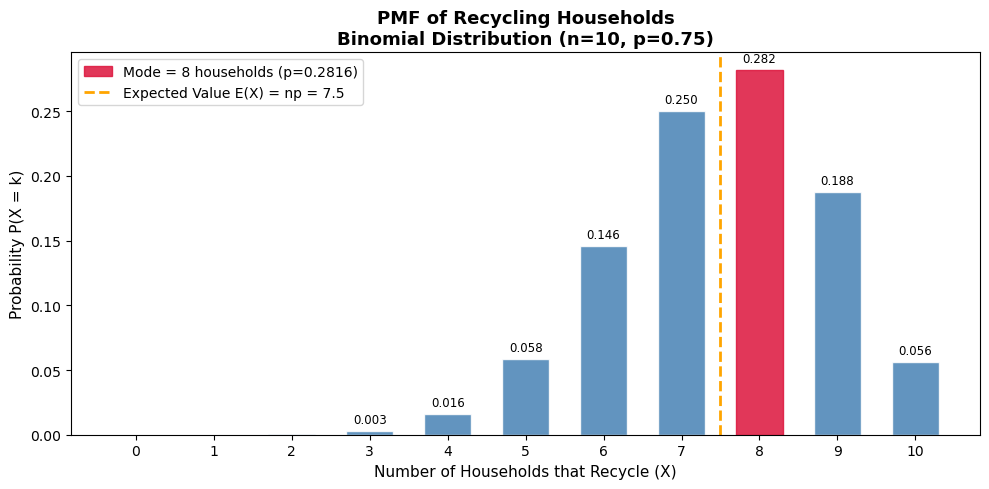

===== PMF of Recycling Households =====
k (Households)         P(X = k)    Cumulative P(X ≤ k)
------------------------------------------------------
0                        0.0000                 0.0000
1                        0.0000                 0.0000
2                        0.0004                 0.0004
3                        0.0031                 0.0035
4                        0.0162                 0.0197
5                        0.0584                 0.0781
6                        0.1460                 0.2241
7                        0.2503                 0.4744
8                        0.2816                 0.7560
9                        0.1877                 0.9437
10                       0.0563                 1.0000

Expected Value E(X):    7.50
Variance Var(X):        1.88
Std Deviation:          1.37
Mode:                   8 households


In [7]:
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10   # Number of households
p = 0.75 # Probability of a household recycling

# All possible values of X (0 to 10 households)
x = np.arange(0, n + 1)

# Calculate PMF for each value of X
pmf = binom.pmf(k=x, n=n, p=p)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(x, pmf, color='steelblue', edgecolor='white', alpha=0.85, width=0.6)

# Highlight the most likely outcome (mode)
mode = x[np.argmax(pmf)]
bars[mode].set_color('crimson')
bars[mode].set_label(f'Mode = {mode} households (p={pmf[mode]:.4f})')

# Annotate each bar with its probability
for i, (xi, pi) in enumerate(zip(x, pmf)):
    if pi > 0.001:  # Skip near-zero bars
        ax.text(xi, pi + 0.004, f'{pi:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.axvline(n * p, color='orange', linewidth=2, linestyle='--', label=f'Expected Value E(X) = np = {n*p:.1f}')

ax.set_title('PMF of Recycling Households\nBinomial Distribution (n=10, p=0.75)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Households that Recycle (X)', fontsize=11)
ax.set_ylabel('Probability P(X = k)', fontsize=11)
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

print("===== PMF of Recycling Households =====")
print(f"{'k (Households)':<18} {'P(X = k)':>12} {'Cumulative P(X ≤ k)':>22}")
print("-" * 54)
for k, prob in zip(x, pmf):
    cdf = binom.cdf(k=k, n=n, p=p)
    print(f"{k:<18} {prob:>12.4f} {cdf:>22.4f}")

print(f"\nExpected Value E(X):    {n * p:.2f}")
print(f"Variance Var(X):        {n * p * (1-p):.2f}")
print(f"Std Deviation:          {np.sqrt(n * p * (1-p)):.2f}")
print(f"Mode:                   {mode} households")

### Exercise 4

Model the time between discoveries of new species in a rainforest using an exponential distribution with a mean discovery rate of 0.3 species per year. Write a Python snippet that calculates the probability of discovering a new species within the next 2 years.


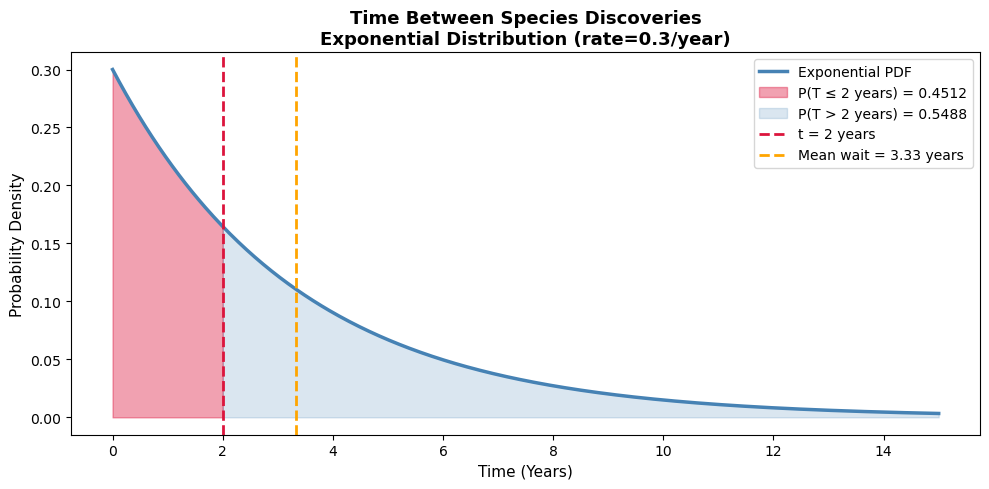

===== Exponential Distribution Summary =====
Discovery Rate (λ):           0.3 species/year
Scale (1/λ):                  3.33 years
Mean Wait Time:               3.33 years
Median Wait Time:             2.31 years

P(discovery within 1 year):   0.2592  (25.92%)
P(discovery within 2 years):  0.4512  (45.12%)
P(discovery within 5 years):  0.7769  (77.69%)
P(no discovery within 2 yrs): 0.5488  (54.88%)


In [9]:
from scipy.stats import expon

rate = 0.3  # Mean discovery rate
time_period = 2  # Time period in years

# Exponential distribution scale = 1/rate (mean time between discoveries)
scale = 1 / rate  # = 3.33 years

# P(T <= 2) — probability of discovering a species within 2 years
p_within_2_years = expon.cdf(x=time_period, scale=scale)

# Extra insights
p_after_2_years  = 1 - p_within_2_years          # P(T > 2)
mean_wait        = expon.mean(scale=scale)         # Expected wait time
median_wait      = expon.median(scale=scale)       # Median wait time
p_within_1_year  = expon.cdf(x=1, scale=scale)    # P(T <= 1)
p_within_5_years = expon.cdf(x=5, scale=scale)    # P(T <= 5)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

t = np.linspace(0, 15, 500)
pdf = expon.pdf(t, scale=scale)

ax.plot(t, pdf, color='steelblue', linewidth=2.5, label='Exponential PDF')

# Shade P(T <= 2)
t_shade = np.linspace(0, time_period, 300)
ax.fill_between(t_shade, expon.pdf(t_shade, scale=scale),
                alpha=0.4, color='crimson', label=f'P(T ≤ 2 years) = {p_within_2_years:.4f}')

# Shade P(T > 2)
t_shade2 = np.linspace(time_period, 15, 300)
ax.fill_between(t_shade2, expon.pdf(t_shade2, scale=scale),
                alpha=0.2, color='steelblue', label=f'P(T > 2 years) = {p_after_2_years:.4f}')

ax.axvline(time_period, color='crimson',linewidth=2, linestyle='--', label=f't = {time_period} years')
ax.axvline(mean_wait,   color='orange',  linewidth=2, linestyle='--', label=f'Mean wait = {mean_wait:.2f} years')

ax.set_title('Time Between Species Discoveries\nExponential Distribution (rate=0.3/year)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (Years)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.legend()

plt.tight_layout()
plt.show()

print("===== Exponential Distribution Summary =====")
print(f"Discovery Rate (λ):           {rate} species/year")
print(f"Scale (1/λ):                  {scale:.2f} years")
print(f"Mean Wait Time:               {mean_wait:.2f} years")
print(f"Median Wait Time:             {median_wait:.2f} years")
print(f"\nP(discovery within 1 year):   {p_within_1_year:.4f}  ({p_within_1_year*100:.2f}%)")
print(f"P(discovery within 2 years):  {p_within_2_years:.4f}  ({p_within_2_years*100:.2f}%)")
print(f"P(discovery within 5 years):  {p_within_5_years:.4f}  ({p_within_5_years*100:.2f}%)")
print(f"P(no discovery within 2 yrs): {p_after_2_years:.4f}  ({p_after_2_years*100:.2f}%)")

### Exercise 5

Given the `flow_rates` of daily river flow rates (in cubic metres per second), assumed to follow a normal distribution, write a Python function to calculate the probability of the flow rate exceeding a specific value (e.g. flood risk assessment).


In [10]:
from scipy.stats import norm

flow_rates = np.array([450, 500, 550, 600, 650, 700, 750, 800, 850, 900]) # Example data for a year
threshold = 700

def flood_risk_probability(flow_rates, threshold):
    mu    = np.mean(flow_rates)   # Sample mean
    sigma = np.std(flow_rates, ddof=1)   # Sample std dev

    # P(X > threshold) = 1 - P(X <= threshold)
    p_exceed = 1 - norm.cdf(x=threshold, loc=mu, scale=sigma)

    # z-score of the threshold
    z_score = (threshold - mu) / sigma

    return p_exceed, mu, sigma, z_score

p_exceed, mu, sigma, z_score = flood_risk_probability(flow_rates, threshold)

# Additional probabilities for context
p_below     = 1 - p_exceed                           # P(X <= threshold)
p_within_1s = norm.cdf(mu + sigma, loc=mu, scale=sigma) - norm.cdf(mu - sigma, loc=mu, scale=sigma)
p_extreme   = 1 - norm.cdf(mu + 2*sigma, loc=mu, scale=sigma)  # P(X > mu + 2σ)

print("===== Flood Risk Assessment =====")
print(f"Mean Flow Rate (μ):            {mu:.2f} m³/s")
print(f"Std Deviation (σ):             {sigma:.2f} m³/s")
print(f"Threshold:                     {threshold} m³/s")
print(f"Z-Score of Threshold:          {z_score:.4f}")
print(f"\nP(flow ≤ {threshold}):           {p_below:.4f}  ({p_below*100:.2f}%)")
print(f"P(flow > {threshold}) — Flood Risk: {p_exceed:.4f}  ({p_exceed*100:.2f}%)")
print(f"\nP(flow within μ ± 1σ):         {p_within_1s:.4f}  ({p_within_1s*100:.2f}%)")
print(f"P(flow > μ + 2σ = {mu+2*sigma:.1f}):  {p_extreme:.4f}  ({p_extreme*100:.2f}%)")

===== Flood Risk Assessment =====
Mean Flow Rate (μ):            675.00 m³/s
Std Deviation (σ):             151.38 m³/s
Threshold:                     700 m³/s
Z-Score of Threshold:          0.1651

P(flow ≤ 700):           0.5656  (56.56%)
P(flow > 700) — Flood Risk: 0.4344  (43.44%)

P(flow within μ ± 1σ):         0.6827  (68.27%)
P(flow > μ + 2σ = 977.8):  0.0228  (2.28%)


## Solutions

### Exercise 1

The function `describe_temperatures` computes the mean, median, and standard deviation of the given temperature data. This helps in understanding the central tendency (mean, median) and variability (standard deviation) of temperature data.


In [11]:
import numpy as np

def describe_temperatures(temperatures):
    mean_temp = np.mean(temperatures)  # Calculate mean
    median_temp = np.median(temperatures)  # Calculate median
    std_temp = np.std(temperatures)  # Calculate standard deviation
    return mean_temp, median_temp, std_temp

# Testing the function
temperatures = np.array([22, 25, 19, 21, 24, 28, 23, 20])
describe_temperatures(temperatures)


(22.75, 22.5, 2.7271780286589284)

### Exercise 2

The binomial distribution is suitable here because each day is an independent trial with two outcomes (observation or no observation). The final probability is computed by subtracting the probability of not observing the species at all (calculated by `binom.pmf(0, n, p)`) from `1`, which gives the probability of at least one observation during the week.


In [13]:
from scipy.stats import binom

# Calculating the probability of observing the species at least once in a week
n = 7  # Number of days in a week
p = 0.1  # Daily observation probability
probability = 1 - binom.pmf(0, n, p)  # Probability of observing at least once
probability

0.5217031000000001

### Exercise 3

The `np.arange(0, n+1)` function generates an array of values from `0` to `n` (`10` in this case), representing all possible outcomes for the number of recycling households. The PMF for these outcomes is computed using `binom.pmf(x, n, p)`, and the results are then plotted as a bar chart, effectively visualising the probability of each outcome (from 0 to 10 recycling households) given a 75% chance of any individual household recycling.

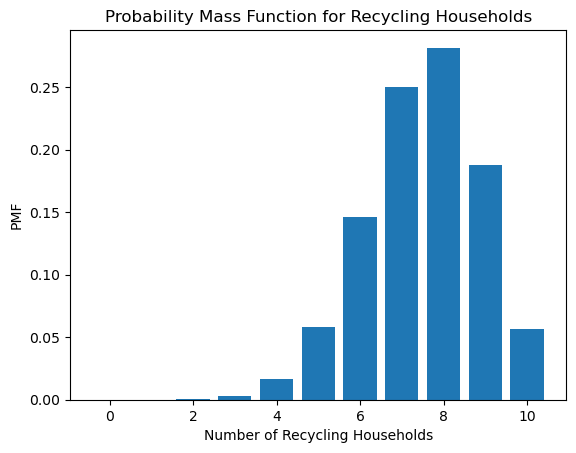

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10  # Number of households
p = 0.75  # Probability of a household recycling
x = np.arange(0, n+1)  # Possible outcomes: 0 to n households
pmf = binom.pmf(x, n, p)  # PMF calculation

# Plotting PMF
plt.bar(x, pmf)
plt.xlabel('Number of Recycling Households')
plt.ylabel('PMF')
plt.title('Probability Mass Function for Recycling Households')
plt.show()

### Exercise 4

The code calculates the cumulative probability of discovering a new species within a two-year period using an exponential distribution with a mean discovery rate of 0.3 species per year.



In [15]:
from scipy.stats import expon

rate = 0.3  # Mean discovery rate
time_period = 2  # Time period in years
probability = expon.cdf(time_period, scale=1/rate)  # Probability of discovery within time period
probability


0.4511883639059735

### Exercise 5


The flood_risk_probability function calculates the probability of river flow rates exceeding a specified threshold (700 cubic metres per second) based on a given set of flow rate data. It first determines the mean (`mu`) and standard deviation (`sigma`) of the provided `flow_rates` array. Then, using the cumulative distribution function (CDF) of the normal distribution (`norm.cdf`), it computes the probability that actual flow rates will be less than the threshold and subtracts this from 1 to get the probability of exceeding that threshold.


In [16]:
from scipy.stats import norm

def flood_risk_probability(flow_rates, threshold):
    mu, sigma = np.mean(flow_rates), np.std(flow_rates)  # Calculate mean and std dev
    probability = 1 - norm.cdf(threshold, mu, sigma)  # Probability of exceeding threshold
    return probability

# Testing the function with example data
flow_rates = np.array([450, 500, 550, 600, 650, 700, 750, 800, 850, 900])
threshold = 700
print(flood_risk_probability(flow_rates, threshold))


0.43090221652450544


#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/refs/heads/master/ALX_banners/ALX_Navy.png"  style="width:140px";/>
</div>